# Self-consistency: mean-field Hubbard antiferromagnetism
So far the Hamiltonian was fixed by hand. Here electrons interact through a local (Hubbard) repulsion,
$$ H_U = U\sum_i c^\dagger_{i\uparrow}c_{i\uparrow}\,c^\dagger_{i\downarrow}c_{i\downarrow} $$
which is quartic and cannot be diagonalized directly. The mean-field (Hartree-Fock) decoupling replaces one operator in each pair by its expectation value,
$$ H_U \approx U\sum_i \Big[\langle n_{i\uparrow}\rangle\, c^\dagger_{i\downarrow}c_{i\downarrow} + \langle n_{i\downarrow}\rangle\, c^\dagger_{i\uparrow}c_{i\uparrow}\Big] $$
turning the problem back into a *single-particle* Hamiltonian whose parameters ($\langle n_{i\sigma}\rangle$) must be found self-consistently: diagonalize, recompute the occupations, rebuild $H$, repeat until converged. On bipartite honeycomb with repulsive $U$ this drives an antiferromagnetic instability once $U$ exceeds a critical value.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

In [2]:
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian()

### Scan the staggered magnetization as a function of U

In [3]:
Us = np.linspace(0.,4.0,15)
Ms = []
for U in Us:
    hscf = h.get_mean_field_hamiltonian(U=U, mf="antiferro", mix=0.9, nk=20)
    mz = hscf.extract("mz")           # magnetization on each sublattice
    Ms.append(abs(mz[0]-mz[1]))       # staggered (Neel) magnetization
    print(f"U={U:.2f}  m_stag={Ms[-1]:.4f}")

U=0.00  m_stag=0.0000
U=0.29  m_stag=0.0000
U=0.57  m_stag=0.0000


U=0.86  m_stag=0.0000
U=1.14  m_stag=0.0001


U=1.43  m_stag=0.0001


U=1.71  m_stag=0.0002


U=2.00  m_stag=0.0006


...

U=2.57  m_stag=0.6531


U=2.86  m_stag=1.1168


U=3.14  m_stag=1.5398


U=3.43  m_stag=1.9378
U=3.71  m_stag=2.3185


U=4.00  m_stag=2.6867


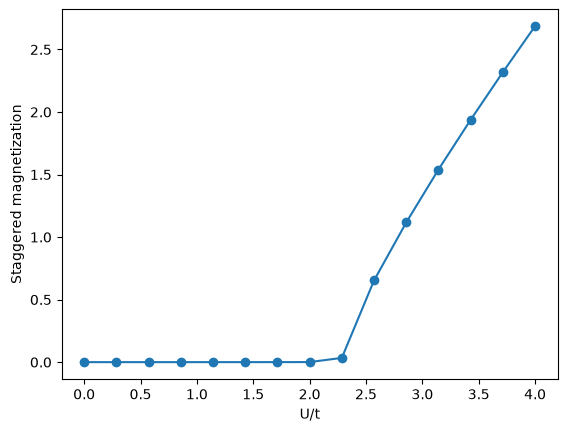

In [4]:
plt.plot(Us,Ms,marker="o")
plt.xlabel("U/t")
plt.ylabel("Staggered magnetization")
plt.show()

### The self-consistent gap
Above the critical $U$, the antiferromagnetic order parameter acts exactly like the sublattice-imbalance mass from the bands notebook, and opens a gap at the Dirac point — but now the mass is generated by the interaction itself, not put in by hand.

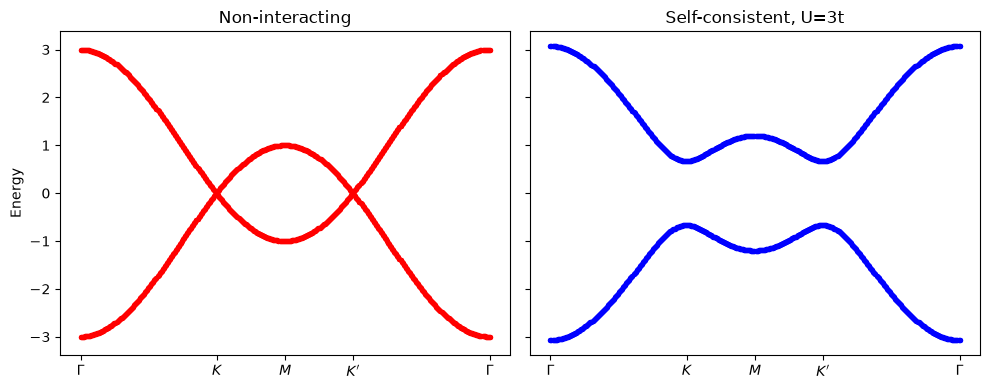

In [5]:
hscf = h.get_mean_field_hamiltonian(U=3.0, mf="antiferro", mix=0.9, nk=20)

(k0,e0) = h.get_bands()
(k1,e1) = hscf.get_bands()

fig, axes = plt.subplots(1,2,figsize=(10,4),sharey=True)
axes[0].scatter(k0/max(k0),e0,c="red",s=8)
axes[0].set_title("Non-interacting")
axes[0].set_xticks([0.,1/3.,0.5,2./3.,1.])
axes[0].set_xticklabels(["$\Gamma$","$K$","$M$","$K'$","$\Gamma$"])
axes[0].set_ylabel("Energy")

axes[1].scatter(k1/max(k1),e1,c="blue",s=8)
axes[1].set_title("Self-consistent, U=3t")
axes[1].set_xticks([0.,1/3.,0.5,2./3.,1.])
axes[1].set_xticklabels(["$\Gamma$","$K$","$M$","$K'$","$\Gamma$"])

plt.tight_layout()
plt.show()